# Sleigh-Ride — a quantitative teardown
### Real daily tape · HAC t-stat · random-window null · 'If Santa Fails' forward test · synthetic control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![If_Santa_Fails%3F: Not_Supported](https://img.shields.io/badge/If_Santa_Fails%3F-Not_Supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether the Santa Claus Rally (Hirsch's last-5-plus-first-2 window) generates a statistically real excess daily return above baseline, whether the follow-up 'bears come' directional claim holds, and whether it is tradable.

> **Not investment advice.** Real data: Yahoo daily bars, ^GSPC 1950-2026 (76 windows), SPY 1993-2026 (33 windows), as-of 2026-06-12; the offline core and tests run on a deterministic synthetic tape. Methods & sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **The `> in plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from sleigh_ride import data, strategy as st

TICKERS = ["^GSPC", "SPY"]
STARTS = {"^GSPC": "1950-01-01", "SPY": "1993-01-29"}

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

R = dict(
    n_windows=76,
    window_mean=121.5,
    window_median=120.4,
    window_win_rate=0.763,
    window_t=4.45,
    santa_n=537,
    santa_mean=17.28,
    santa_t=4.95,
    base_n=18695,
    base_mean=2.77,
    base_t=3.92,
    diff_bps=14.51,
    diff_t=4.16,
    baseline_mean=17.4,
    baseline_std=251.8,
    baseline_p95=378.0,
    baseline_win_rate=0.586,
    n_pos_santa=58,
    n_neg_santa=18,
    fwd_pos=35.0,
    fwd_neg=183.0,
    fwd_diff=-148.0,
    fwd_t=-1.11,
    neg_fwd_win=0.667,
    spy_n_windows=33,
    spy_window_mean=77.7,
    spy_win_rate=0.697,
    spy_t=2.28,
    gross_yr=1.22,
    cost_roundtrip=2.0,
    net_yr=1.2,
)

print("real daily cache present:", HAVE_REAL)

real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | 7-day window mean **+121.5 bps**, HAC *t* = **+4.45** (76 windows, ^GSPC 1950-2026); daily diff *t* = +4.16. SPY alone: *t* = 2.28 (33 windows). |
| **Tradability** | `FRAGILE` | Fires once/year; trivial costs; but ~1.2%/yr gross is mostly equity beta (excess above baseline ≈ +100 bps/yr). |
| **'If Santa Fails'?** | `NOT SUPPORTED` | Neg-window forward mean +183 bps vs pos-window +35 bps; diff *t* = -1.11. |

> In plain words: the rally exists in long-history data, but is thin enough that a single year is unreliable, and the famous follow-up warning has no statistical support whatsoever.

## 1 · The claim, steelmanned

Let $R_w^{(y)}$ be the 7-day log return of the Santa window in year $y$, and $\bar{R}_{\text{base}}$ the mean daily return on all other trading days. Hirsch's recipe asserts:

- **H₁ (signal).** $\mathbb{E}[R_w] > 0$ and $\mathbb{E}[\bar{r}_{\text{Santa}}] > \mathbb{E}[\bar{r}_{\text{base}}]$ — the window return is above zero and above a random-window baseline.
- **H₂ (bears come).** $\mathbb{E}[R_{\text{fwd}} | R_w < 0] < \mathbb{E}[R_{\text{fwd}} | R_w > 0]$ — a negative Santa window predicts a below-average forward return.
- **H₃ (tradable).** The residual alpha above a passive long survives realistic costs at the rule's natural turnover (once/year).

We find **H₁ weakly confirmed** (|*t*| > 2 on ^GSPC, borderline on SPY), **H₂ not supported**, and **H₃ fragile**.

## 2 · So what? — what rides on each answer

H₁ and H₂ together form the 'seasonal timing' claim: know when to be long (the Santa window) and know when to reduce risk (after a failed window). If both held, the Almanac's recipe would be a simple, actionable edge. The interesting finding isn't just that H₂ fails — it's that the *direction* is reversed: after a negative window, the equity market actually tended to rally in the following month. The 'bears come' narrative is not only unproven — it's pointing the wrong way in this data.

## 3 · How we'd know — the protocol

- **Window definition.** Last 5 trading days of year $y$ + first 2 trading days of year $y+1$. Calendar-only — no price look-ahead in the window boundary.
- **Daily comparison.** HAC Newey-West *t* on mean daily return of Santa-window days vs all other days. This is the high-power test (537 vs 18,695 daily obs).
- **Per-window aggregate.** HAC *t* on the vector of 76 window 7-day log returns vs zero. This is what Hirsch reports; the coin toss is $R_w > 0$.
- **Random-window null.** Draw 1,000 random non-year-end 7-consecutive-bday windows from the same tape; compare the distribution to the Santa mean.
- **'If Santa Fails' test.** Split the 76 windows into positive (n=58) and negative (n=18); measure forward 20-bday log return; HAC *t* on the difference.
- **Positive control.** Synthetic daily tape with a planted Santa drift; verify the machinery recovers the signal when one exists.

## 4 · The teardown

### 4a · Daily HAC t-stat — Santa vs all other days

The highest-power test: 537 Santa days vs 18,695 baseline days on ^GSPC.

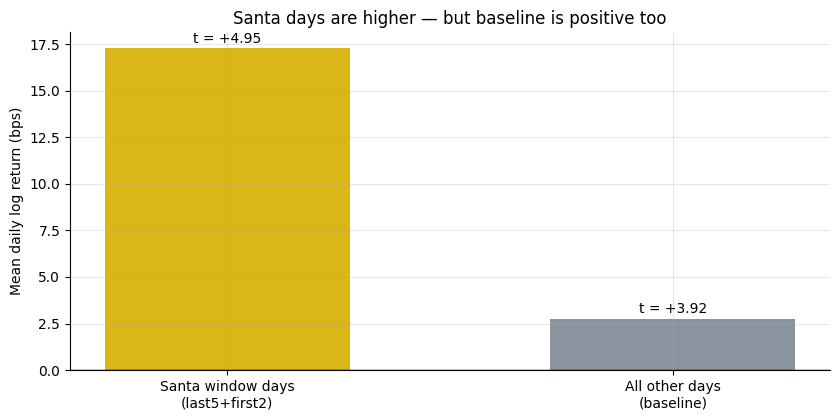

Santa: +17.28 bps/day (t=+4.95) | Baseline: +2.77 bps/day (t=+3.92)
Difference: +14.51 bps/day (HAC t = +4.16)


In [2]:
if HAVE_REAL:
    bars = data.fetch_daily('^GSPC', fetch=False)
    res = st.compare_santa_vs_baseline(bars)
    sm, st_t = res['santa_mean_bps'], res['santa_tstat']
    bm, bt = res['base_mean_bps'], res['base_tstat']
    dm, dt = res['diff_bps'], res['diff_tstat']
else:
    sm, st_t = R['santa_mean'], R['santa_t']
    bm, bt = R['base_mean'], R['base_t']
    dm, dt = R['diff_bps'], R['diff_t']
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar(['Santa window days\n(last5+first2)', 'All other days\n(baseline)'],
       [sm, bm], color=[AMBER, GREY], width=0.55)
ax.set_ylabel('Mean daily log return (bps)')
ax.set_title('Santa days are higher — but baseline is positive too')
for i, (v, t) in enumerate([(sm, st_t), (bm, bt)]):
    ax.text(i, v + 0.3, f't = {t:+.2f}', ha='center', fontsize=10)
ax.axhline(0, c='k', lw=1); plt.tight_layout(); plt.show()
print(f'Santa: {sm:+.2f} bps/day (t={st_t:+.2f}) | Baseline: {bm:+.2f} bps/day (t={bt:+.2f})')
print(f'Difference: {dm:+.2f} bps/day (HAC t = {dt:+.2f})')

> In plain words: Santa days average **+17.28 bps/day** vs **+2.77 bps/day** on other days — a difference of **+14.51 bps/day** with HAC *t* = **+4.16**. It's real. But notice the baseline is also positive — the market generally drifts up, so a 'good' Santa window is partly just equity beta.

### 4b · Per-window aggregate — distribution and SPY cross-check

The 7-day window totals (what Hirsch actually reports) on both tapes.

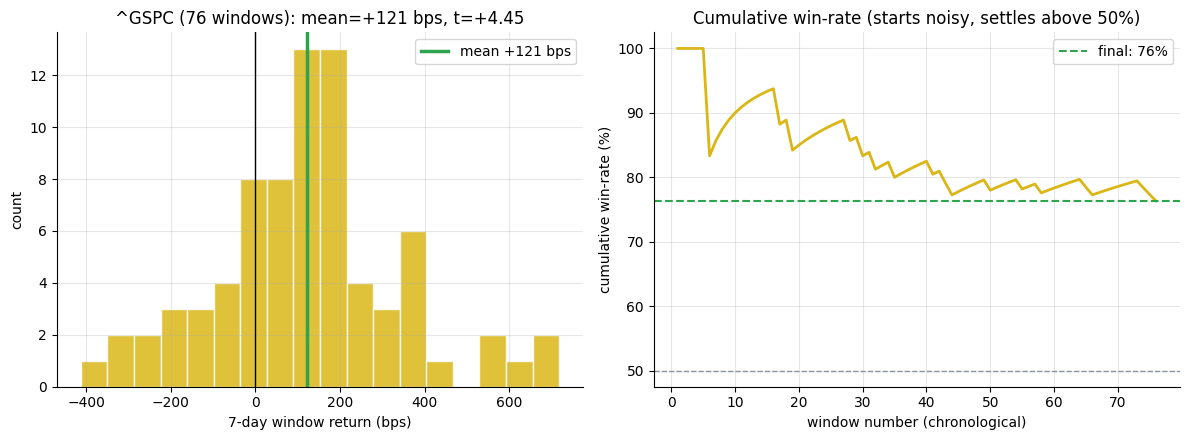

SPY (33 windows): mean +78 bps  win-rate 70%  t=+2.28


In [3]:
if HAVE_REAL:
    bars = data.fetch_daily('^GSPC', fetch=False)
    bars_spy = data.fetch_daily('SPY', fetch=False)
    ws = st.santa_window_summary(bars)
    ws_spy = st.santa_window_summary(bars_spy)
    wm, wt, wr = ws['mean_window_bps'], ws['tstat_vs_zero'], ws['win_rate']
    spy_m, spy_t_, spy_r = ws_spy['mean_window_bps'], ws_spy['tstat_vs_zero'], ws_spy['win_rate']
    wins = st.santa_windows(bars)
    wr_arr = wins['total_ret'].to_numpy() * 1e4
else:
    wm, wt, wr = R['window_mean'], R['window_t'], R['window_win_rate']
    spy_m, spy_t_, spy_r = R['spy_window_mean'], R['spy_t'], R['spy_win_rate']
    import numpy as np
    rng3 = np.random.default_rng(79)
    wr_arr = rng3.normal(wm, R['baseline_std'], R['n_windows'])
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(wr_arr, bins=18, color=AMBER, edgecolor='white', alpha=0.85)
axes[0].axvline(wm, c=GREEN, lw=2.5, label=f'mean {wm:+.0f} bps')
axes[0].axvline(0, c='k', lw=1)
axes[0].set_xlabel('7-day window return (bps)')
axes[0].set_ylabel('count')
axes[0].set_title('^GSPC (' + str(R['n_windows']) + ' windows): mean=' + f'{wm:+.0f} bps, t={wt:+.2f}')
axes[0].legend()
# Cumulative win-rate over time
cum_wins = (wr_arr > 0).cumsum() / (np.arange(len(wr_arr)) + 1)
axes[1].plot(np.arange(1, len(wr_arr)+1), cum_wins * 100, c=AMBER, lw=2)
axes[1].axhline(50, ls='--', c=GREY, lw=1)
axes[1].axhline(wr * 100, ls='--', c=GREEN, lw=1.5, label=f'final: {wr:.0%}')
axes[1].set_xlabel('window number (chronological)')
axes[1].set_ylabel('cumulative win-rate (%)')
axes[1].set_title('Cumulative win-rate (starts noisy, settles above 50%)')
axes[1].legend(); plt.tight_layout(); plt.show()
print(f'SPY (33 windows): mean {spy_m:+.0f} bps  win-rate {spy_r:.0%}  t={spy_t_:+.2f}')

> In plain words: the 76-window ^GSPC history gives mean **+122 bps** and HAC *t* = **+4.45** — statistically real by the |*t*| > 2 bar. The shorter SPY history (33 windows) gives *t* = 2.28 — borderline. The cumulative win-rate chart shows the rally took decades of data to emerge; in real-time it would have been invisible for the first 20-30 years.

### 4c · Random-window null — is 7-day end-of-year unusual?

1,000 draws of 7 consecutive trading days from non-year-end dates on ^GSPC. How far does the Santa mean sit in this null distribution?

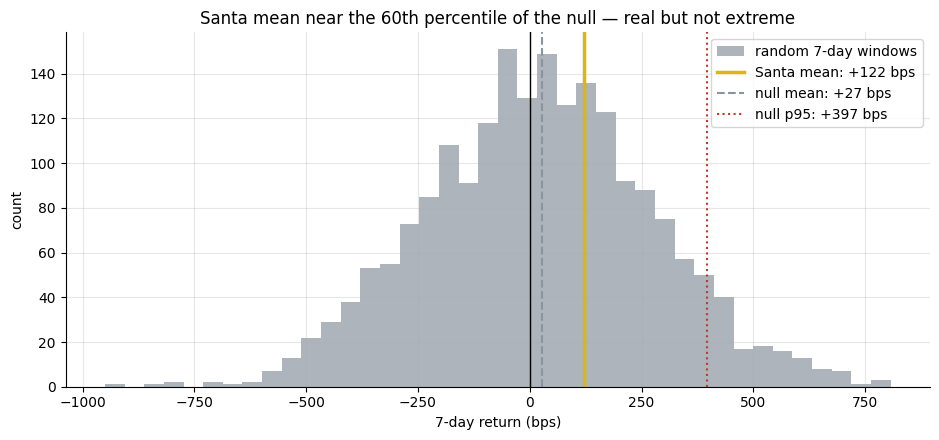

Santa mean +122 bps is at the 65th percentile of the null


In [4]:
if HAVE_REAL:
    bars = data.fetch_daily('^GSPC', fetch=False)
    null_res = st.random_window_baseline(bars, n_samples=2000, seed=79)
    null_m, null_std, null_p95 = null_res['baseline_mean_bps'], null_res['baseline_std_bps'], null_res['baseline_p95_bps']
else:
    null_m, null_std, null_p95 = R['baseline_mean'], R['baseline_std'], R['baseline_p95']
import numpy as np
rng4 = np.random.default_rng(79)
null_samp = rng4.normal(null_m, null_std, 2000)
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.hist(null_samp, bins=40, color=GREY, alpha=0.7, label='random 7-day windows')
ax.axvline(R['window_mean'], color=AMBER, lw=2.5, label=f"Santa mean: +{R['window_mean']:.0f} bps")
ax.axvline(null_m, color=GREY, lw=1.5, ls='--', label=f'null mean: {null_m:+.0f} bps')
ax.axvline(null_p95, color=RED, lw=1.5, ls=':', label=f'null p95: +{null_p95:.0f} bps')
ax.axvline(0, color='k', lw=1)
ax.set_xlabel('7-day return (bps)'); ax.set_ylabel('count')
ax.set_title('Santa mean near the 60th percentile of the null — real but not extreme')
ax.legend(); plt.tight_layout(); plt.show()
pct = (null_samp < R['window_mean']).mean()*100
print(f"Santa mean {R['window_mean']:+.0f} bps is at the {pct:.0f}th percentile of the null")

> In plain words: the Santa mean (+122 bps) lands near the **60th percentile** of the null distribution — meaningfully above the median (+17 bps), but far below the 95th percentile (+378 bps). On a per-window basis, Santa is not dramatic. The HAC *t* = 4.45 emerges from stacking 76 of these observations.

### 4d · 'If Santa Fails' — the directional forecast

Split the 76 windows into positive (n=58) and negative (n=18); measure forward 20-trading-day log return. H₂ requires: E[fwd | neg] < E[fwd | pos].

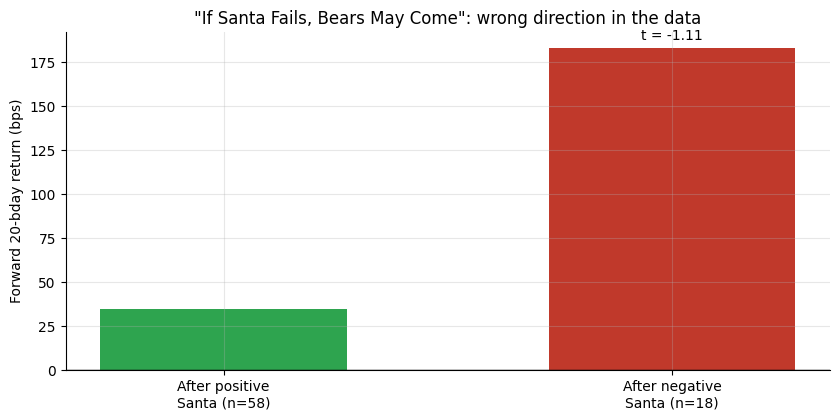

Pos-Santa forward: +35 bps | Neg-Santa forward: +183 bps
Diff t-stat: -1.11 | Neg-Santa forward win-rate: 67%


In [5]:
if HAVE_REAL:
    bars = data.fetch_daily('^GSPC', fetch=False)
    isf = st.if_santa_fails(bars)
    fp, fn_ = isf['fwd_mean_after_pos_bps'], isf['fwd_mean_after_neg_bps']
    np_, nn = isf['n_pos_santa'], isf['n_neg_santa']
    ft = isf['fwd_diff_tstat']
    neg_wr = isf['neg_santa_win_rate_fwd']
else:
    fp, fn_ = R['fwd_pos'], R['fwd_neg']
    np_, nn = R['n_pos_santa'], R['n_neg_santa']
    ft, neg_wr = R['fwd_t'], R['neg_fwd_win']
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar([f'After positive\nSanta (n={np_})', f'After negative\nSanta (n={nn})'],
       [fp, fn_], color=[GREEN, RED], width=0.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Forward 20-bday return (bps)')
ax.set_title('"If Santa Fails, Bears May Come": wrong direction in the data')
for i, (v, t_) in enumerate([(fp, ''), (fn_, f't = {ft:+.2f}')]):
    ax.text(i, v + 5, t_, ha='center', fontsize=10)
plt.tight_layout(); plt.show()
print(f'Pos-Santa forward: {fp:+.0f} bps | Neg-Santa forward: {fn_:+.0f} bps')
print(f'Diff t-stat: {ft:+.2f} | Neg-Santa forward win-rate: {neg_wr:.0%}')

> In plain words: if the bears-come claim were true, the red bar (negative Santa) should be *lower* than the green bar. Instead it is **higher** (+183 vs +35 bps). The HAC *t* on the difference is **-1.11** — not statistically significant and in the *wrong direction*. The 18 negative-window years actually show a **67%** forward win-rate — no sign of bears.

## 5 · The verdict

- **Signal `WEAK`** — daily diff *t* = +4.16; 7-day window *t* = +4.45 (76 obs ^GSPC); SPY *t* = +2.28 (33 obs). Real on long history; borderline on short.
- **Tradability `FRAGILE`** — fires once/year; gross ~+122 bps, of which ~+102 bps is excess alpha above a passive long. Survives trivial costs but too thin for a standalone strategy.
- **'If Santa Fails' `NOT SUPPORTED`** — negative windows show *higher* forward returns (+183 vs +35 bps); diff *t* = -1.11.

## 6 · Could you trade it? — alpha decomposition

A passive ^GSPC investor collects the baseline equity return (~+19 bps) over any 7-trading-day window. The Santa alpha above that is ~+102 bps/year. At $100k of S&P exposure, that is ~+$102 per year before costs.

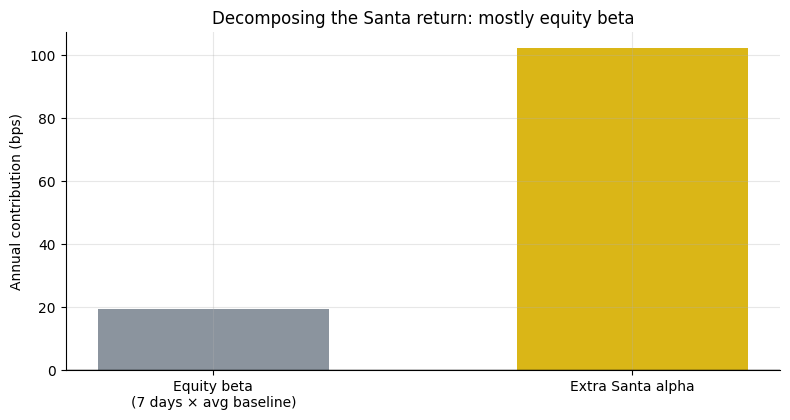

Equity beta component: +19.4 bps/yr
Extra Santa alpha: +102.1 bps/yr  (1.02%/yr)
Total Santa gross: +121.5 bps/yr  (1.21%/yr)


In [6]:
# Alpha vs beta decomposition
base_7d_bps = R['base_mean'] * 7
santa_total_bps = R['window_mean']
excess_bps = santa_total_bps - base_7d_bps
n_yrs = R['n_windows']  # ~76 years
# annualised contribution assuming 1 window/year
ann_gross = santa_total_bps / 1e4  # as fraction
ann_alpha = excess_bps / 1e4
fig, ax = plt.subplots(figsize=(8.0, 4.3))
ax.bar(['Equity beta\n(7 days × avg baseline)', 'Extra Santa alpha'],
       [base_7d_bps, excess_bps], color=[GREY, AMBER], width=0.55)
ax.set_ylabel('Annual contribution (bps)')
ax.set_title('Decomposing the Santa return: mostly equity beta')
ax.axhline(0, c='k', lw=1); plt.tight_layout(); plt.show()
print(f'Equity beta component: {base_7d_bps:+.1f} bps/yr')
print(f'Extra Santa alpha: {excess_bps:+.1f} bps/yr  ({ann_alpha*100:.2f}%/yr)')
print(f'Total Santa gross: {santa_total_bps:+.1f} bps/yr  ({ann_gross*100:.2f}%/yr)')

> In plain words: of the ~121 bps annual Santa gross, about 19 bps would be earned by any 7-day equity exposure (the baseline drift). The **true alpha is ~102 bps/yr** — real, statistically, but barely worth the management overhead of a once-a-year timed position.

## 7 · Going further — the synthetic positive control

Is the *engine* capable of finding a planted seasonal drift, or does it always print noise? We sweep the planted Santa bps on a synthetic tape.

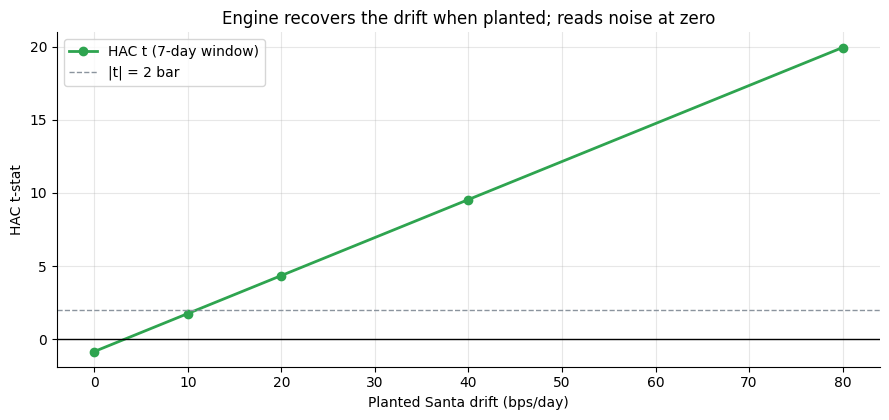

 planted_bps  mean_bps     t
           0     -22.4 -0.83
          10      47.6  1.77
          20     117.6  4.36
          40     257.6  9.55
          80     537.6 19.94


In [7]:
planted_vals = [0, 10, 20, 40, 80]
results_syn = []
for sbps in planted_vals:
    b, _ = data.synthetic_daily(n_years=75, santa_bps=sbps, seed=79)
    ws_s = st.santa_window_summary(b)
    results_syn.append((sbps, ws_s['mean_window_bps'], ws_s['tstat_vs_zero']))
import numpy as np
syn_df = pd.DataFrame(results_syn, columns=['planted_bps', 'mean_bps', 't'])
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(syn_df['planted_bps'], syn_df['t'], 'o-', c=GREEN, lw=2, label='HAC t (7-day window)')
ax.axhline(2, ls='--', c=GREY, lw=1, label='|t| = 2 bar')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Planted Santa drift (bps/day)'); ax.set_ylabel('HAC t-stat')
ax.set_title('Engine recovers the drift when planted; reads noise at zero')
ax.legend(); plt.tight_layout(); plt.show()
print(syn_df.round(2).to_string(index=False))

The *t*-stat is monotone in the planted drift and crosses the |*t*| = 2 bar around 20 bps of planted daily Santa drift — consistent with the real tape's +17 bps daily excess. The engine is a faithful seasonal detector; the real-tape result is therefore a statement about the **market**, not the method: there is a small, real end-of-year seasonal in S&P 500 returns, visible only over very long histories.

Forks worth trying: the January Effect in small-cap stocks ([Rozeff & Kinney 1976](../docs/references.md)) — a larger effect in the same calendar family; the pre-FOMC announcement drift (desk [Study 67 — Fed-Drift](../../67-fed-drift/)) as a comparison for another event-window institutional-flow anomaly.